In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# Data Loading and Preprocessing

In [2]:
df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [3]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# Imputing Missing Values with Mean

In [7]:
df.fillna(df.mean(),inplace=True)

In [8]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [9]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [10]:
x=df.iloc[:,:-1]
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.200000,4.0900,1,296,15.3,396.90,4.980000
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.900000,4.9671,2,242,17.8,396.90,9.140000
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.100000,4.9671,2,242,17.8,392.83,4.030000
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.800000,6.0622,3,222,18.7,394.63,2.940000
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.200000,6.0622,3,222,18.7,396.90,12.715432
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.100000,2.4786,1,273,21.0,391.99,12.715432
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.700000,2.2875,1,273,21.0,396.90,9.080000
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.000000,2.1675,1,273,21.0,396.90,5.640000
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.300000,2.3889,1,273,21.0,393.45,6.480000


In [11]:
y=df["MEDV"]
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

# Splitting the Data into Training and Testing Sets

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.000000,18.10,0.0,0.6140,5.304,97.300000,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.000000,8.14,0.0,0.5380,5.834,56.500000,4.4986,4,307,21.0,395.62,8.47
332,0.03466,11.211934,6.06,0.0,0.4379,6.031,23.300000,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.000000,18.10,0.0,0.6140,6.103,68.518519,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.000000,8.14,0.0,0.5380,5.727,69.500000,3.7965,4,307,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.000000,8.56,0.0,0.5200,5.836,91.900000,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.000000,6.96,0.0,0.4640,5.856,42.100000,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.000000,2.01,0.0,0.4350,6.635,29.700000,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.000000,18.10,0.0,0.7400,6.629,94.600000,2.1247,24,666,20.2,109.85,23.27


In [16]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,11.083992,0.0,0.510,6.416,68.518519,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.410000,1.0,0.447,6.758,32.900000,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.740000,0.0,0.609,5.983,98.800000,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.810000,0.0,0.413,6.065,7.800000,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.100000,0.0,0.713,6.297,91.800000,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,18.81100,0.0,18.100000,0.0,0.597,4.628,100.000000,1.5539,24,666,20.2,28.79,34.37
436,14.42080,0.0,18.100000,0.0,0.740,6.461,93.300000,2.0026,24,666,20.2,27.49,18.05
411,14.05070,0.0,18.100000,0.0,0.597,6.657,100.000000,1.5275,24,666,20.2,35.05,21.22
86,0.05188,0.0,4.490000,0.0,0.449,6.015,45.100000,4.4272,3,247,18.5,395.99,12.86


In [17]:
y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: MEDV, Length: 404, dtype: float64

In [18]:
y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: MEDV, Length: 102, dtype: float64

In [19]:
print(f"Shape of X_train: {X_train.shape}")

Shape of X_train: (404, 13)


In [20]:
print(f"Shape of X_test: {X_test.shape}")

Shape of X_test: (102, 13)


In [21]:
print(f"Shape of y_train: {y_train.shape}")

Shape of y_train: (404,)


In [22]:
print(f"Shape of y_test: {y_test.shape}")

Shape of y_test: (102,)


# Training the Linear Regression Model

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

In [26]:
X_train[ :5]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.000000,18.10,0.0,0.6140,5.304,97.300000,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.000000,8.14,0.0,0.5380,5.834,56.500000,4.4986,4,307,21.0,395.62,8.47
332,0.03466,11.211934,6.06,0.0,0.4379,6.031,23.300000,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.000000,18.10,0.0,0.6140,6.103,68.518519,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.000000,8.14,0.0,0.5380,5.727,69.500000,3.7965,4,307,21.0,390.95,11.28


In [27]:
y_train[ :5]

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
Name: MEDV, dtype: float64

In [28]:
y_train_pred[ :5]

array([10.70222007, 19.39305504, 22.63386363, 12.54692546, 18.39858594])

In [29]:
X_test[ :5]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,11.083992,0.0,0.510,6.416,68.518519,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.410000,1.0,0.447,6.758,32.900000,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.740000,0.0,0.609,5.983,98.800000,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.810000,0.0,0.413,6.065,7.800000,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.100000,0.0,0.713,6.297,91.800000,2.3682,24,666,20.2,385.09,17.27


In [30]:
y_test[ :5]

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
Name: MEDV, dtype: float64

In [31]:
y_test_pred[ :3]

array([29.14324958, 36.53566752, 14.49251294])

# Model Evaluation

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
def training_eval(actual,predicted):
    mae = mean_absolute_error(actual,predicted)
    mse = mean_squared_error(actual,predicted)
    rmse = np.sqrt(mean_squared_error(actual,predicted))
    r2 = r2_score(actual,predicted)

    print(f'MAE:{mae}')
    print(f'MSE:{mse}')
    print(f'RMSE:{rmse}')
    print(f'R2 Score:{r2}')

    plt.scatter(actual,predicted,color="b")
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()],ls="--", lw=2)
    plt.title("fit line")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()

MAE:3.358334361003426
MSE:22.410733172287667
RMSE:4.733997588960905
R2 Score:0.7420299863537105


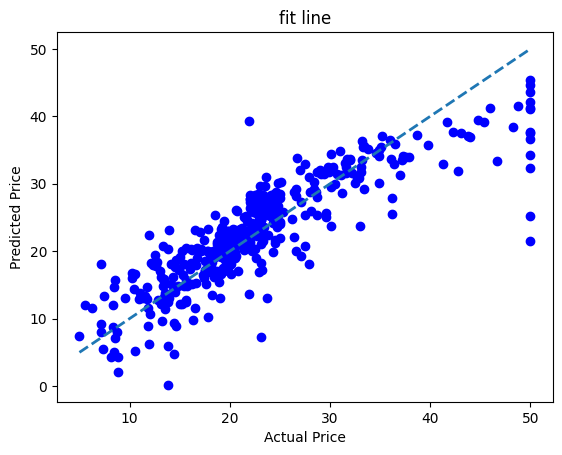

In [34]:
training_eval(y_train,y_train_pred)

MAE:3.149923357345782
MSE:25.017672023842703
RMSE:5.001766890194174
R2 Score:0.658852019550814


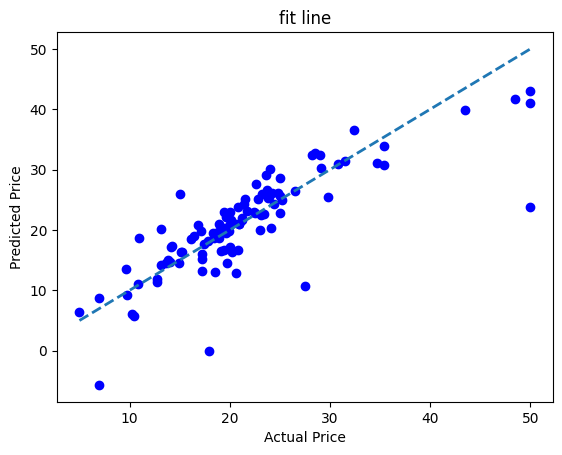

In [35]:
training_eval(y_test,y_test_pred)

# Training Model(Random Forest)

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
random_model = RandomForestRegressor()
random_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_train_pred_random=random_model.predict(X_train)
y_test_pred_random=random_model.predict(X_test)

In [39]:
def training_eval(actual,predicted):
    mae = mean_absolute_error(actual,predicted)
    mse = mean_squared_error(actual,predicted)
    rmse = np.sqrt(mean_squared_error(actual,predicted))
    r2 = r2_score(actual,predicted)

    print(f'MAE:{mae}')
    print(f'MSE:{mse}')
    print(f'RMSE:{rmse}')
    print(f'R2 Score:{r2}')

    plt.scatter(actual,predicted,color="b")
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()],ls="--", lw=2)
    plt.title("fit line Regression ")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()

MAE:0.9318242574257417
MSE:2.4015945173267346
RMSE:1.5497078812881913
R2 Score:0.9723552386419141


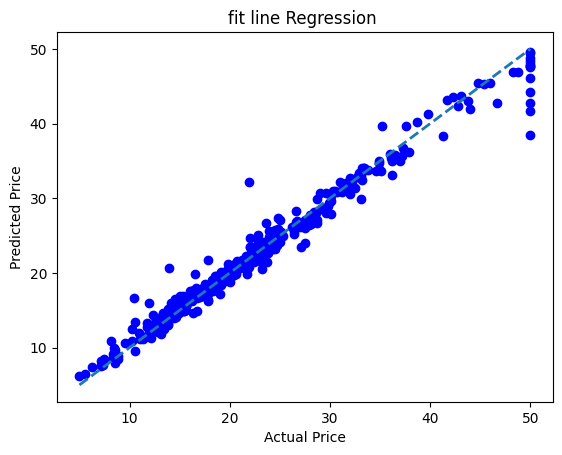

In [40]:
training_eval(y_train,y_train_pred_random)

MAE:2.1551372549019616
MSE:9.925528078431388
RMSE:3.1504806107055137
R2 Score:0.8646527200603832


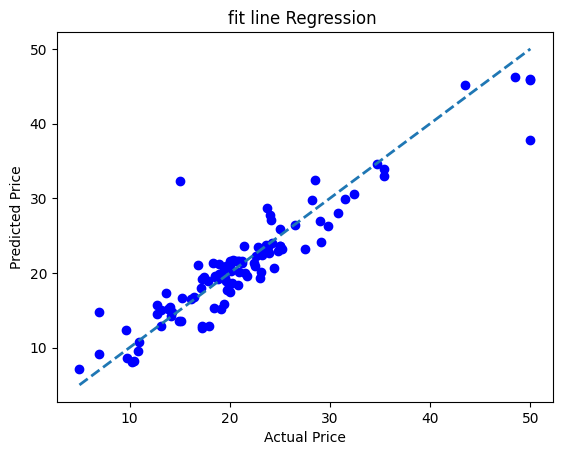

In [41]:
training_eval(y_test,y_test_pred_random)